# Programa de Capacitação de Processamento Digital de Sinais


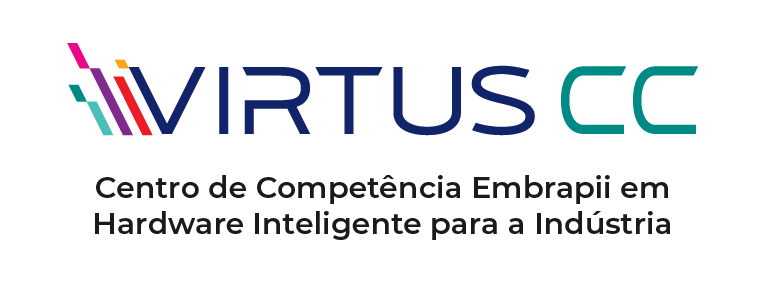


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 3 — Processamento Digital de Sinais

Capítulo 3 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 3

**O Capítulo 3 apresenta os conceitos de DFT e implementações de FFT:**

- Análise de Frequência de Sinais Discretos: Por que representar sinais no domínio da frequência.

- A Transformada de Fourier Discreta (DFT): A versão computacional da análise de Fourier.

- Definição e Propriedades Principais.

A **Transformada Rápida de Fourier (FFT)** não é uma nova transformada, mas sim uma família de algoritmos extremamente eficientes para calcular a DFT.

- A ineficiência do cálculo direto da DFT: O cálculo da DFT diretamente por sua definição exige um número de operações na ordem de **$O(N^2)$**, onde $N$ é o número de amostras. Isso torna o processo inviável para sequências longas.

- O princípio da "divisão e conquista": A base dos algoritmos FFT é quebrar uma DFT de $N$ pontos em DFTs menores, de forma recursiva. Os resultados dessas DFTs menores são então combinados para produzir o resultado final.


- Algoritmos Clássicos: Os algoritmos mais comuns que implementam essa estratégia são:
    - Decimação no Tempo (DIT - *Decimation-In-Time*)
    - Decimação na Frequência (DIF - *Decimation-In-Frequency*)


- O ganho de performance: Ao utilizar a estratégia de "divisão e conquista", os algoritmos FFT reduzem drasticamente a complexidade computacional para a ordem de **$O(N \log N)$**, representando um ganho de performance massivo e tornando a análise de frequência uma ferramenta prática na computação moderna.

- Métodos Overlap-Add e Overlap-Save 

- Convolução Circular vs. Linear: Como a DFT modifica a operação de convolução e como usar isso a nosso favor.

## Objetivos Principais:
-  Implementar DFT manualmente e verificar propriedades como simetria e periodicidade.
-   Implementar o algoritmo da FFT e comparar tempo de execução e resultado com a DFT
-  Simular convolução circular via DFT e comparar com convolução linear.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

# Importando as Bibliotecas


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  
from numba import njit, jit , vectorize , prange

#  Transformada Discreta de Fourier (DFT) e Análise do Código

## 1. Introdução à DFT

A **Transformada Discreta de Fourier (DFT)** permite transformar um sinal do **domínio do tempo** para o **domínio da frequência**.


Para um sinal discreto \(x[n]\) de comprimento \(N\), a DFT é:

$$
X[k] \;=\; \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}, \qquad k = 0,1,\dots,N-1.
$$

Para normalização (preservar energia), usa-se:

$$
X_{\mathrm{norm}}[k] \;=\; \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n]\,e^{-j\frac{2\pi k n}{N}}.
$$


## 2. Zero Padding e Truncamento

Quando o tamanho do sinal \( L \) **não coincide** com o tamanho escolhido para a DFT \( N \), duas situações podem ocorrer:

### 2.1 Zero Padding (\( L < N \))
Adiciona zeros ao final do sinal para que ele tenha comprimento \( N \).  
Essa técnica **não altera o conteúdo do sinal**, mas aumenta a **resolução na frequência**.

$$
x_{zp}[n] =
\begin{cases}
x[n], & 0 \le n < L,\\[4pt]
0, & L \le n < N.
\end{cases}
$$

### 2.2 Truncamento (\( L > N \))
Corta as amostras excedentes do sinal para que ele caiba em \( N \).  
Essa técnica **modifica o sinal original**, podendo introduzir distorções no espectro.

$$
x_{\text{tr}}[n] = x[n], \qquad 0 \le n < N.
$$

Sinal x1[n]: 50 amostras
Sinal x2[n]: 100 amostras


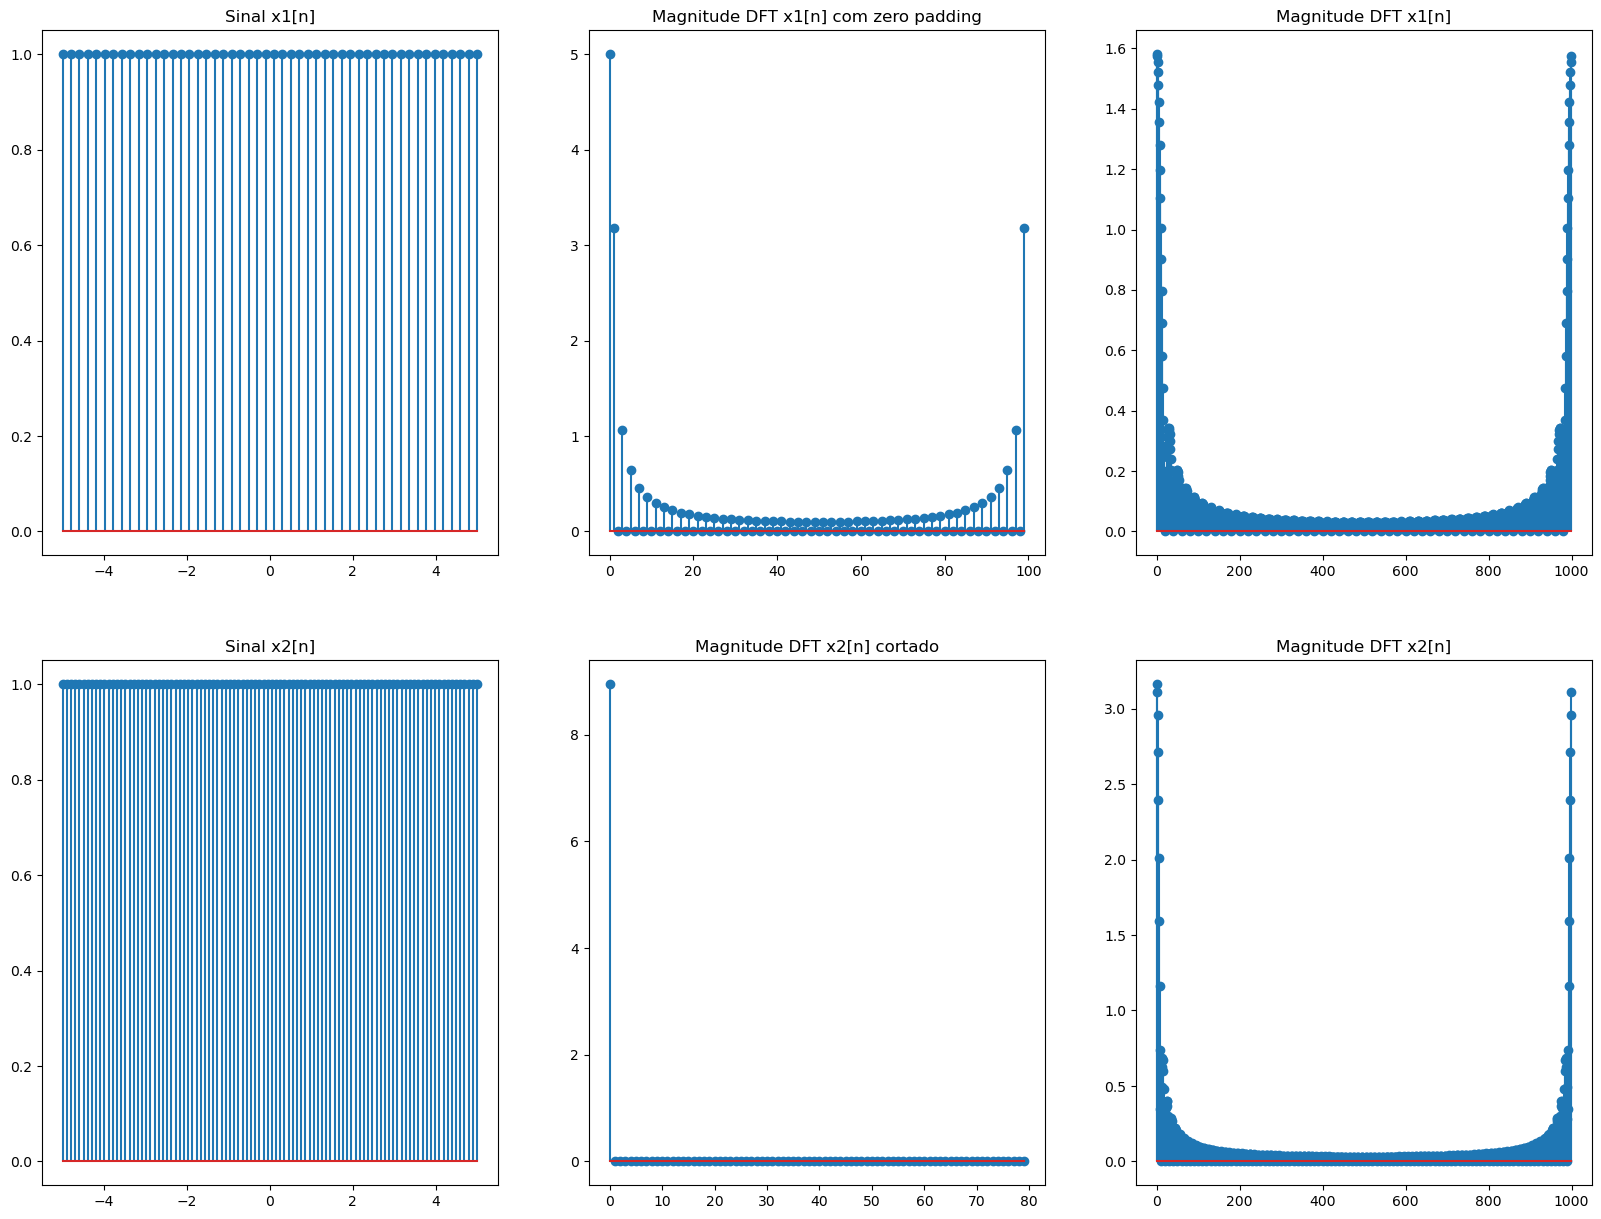

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

L1= 50
N1= 100

L2=100
N2=80 

n1= np.linspace(-5,5,L1)
n2= np.linspace(-5,5,L2)

x1= np.where(np.abs(n1)<10,1,0) #sinal retangular
x2= np.where(np.abs(n2)<10,1,0) #sinal retangular



X1_DFT= DFT_func(x1,N=N1) #DFT do sinal x1, L1=50 < N1=100, com zero padding

X2_DFT= DFT_func(x2,N=N2) #DFT do sinal x2, L2=100 > N2=80, truncado

X3_DFT= DFT_func(x1,N=1000) #DFT do sinal x2, L2=100 < N=1000

X4_DFT= DFT_func(x2,N=1000) #DFT do sinal x2, L2=100 > N=1000

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n]:', len(x1), 'amostras')
print('Sinal x2[n]:', len(x2), 'amostras')

## Otimização de Código

Primeira Compilação com Numba (pode demorar um pouco)...
Compilação concluída. Iniciando os testes de tempo...
Para N= 64...
Tempo DFT com python puro: 0.003450899850577116 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0002593998797237873 segundos
Para N= 128...
Tempo DFT com python puro: 0.013691999949514866 segundos
Tempo DFT tempo com python com njit paralelizado: 0.00014639971777796745 segundos
Para N= 256...
Tempo DFT com python puro: 0.05409620003774762 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0002804999239742756 segundos
Para N= 512...
Tempo DFT com python puro: 0.22129999985918403 segundos
Tempo DFT tempo com python com njit paralelizado: 0.000646399799734354 segundos
Para N= 1024...
Tempo DFT com python puro: 0.8835226995870471 segundos
Tempo DFT tempo com python com njit paralelizado: 0.0014875996857881546 segundos
Para N= 2048...
Tempo DFT com python puro: 3.5887406999245286 segundos
Tempo DFT tempo com python com njit paralelizado: 0.00532

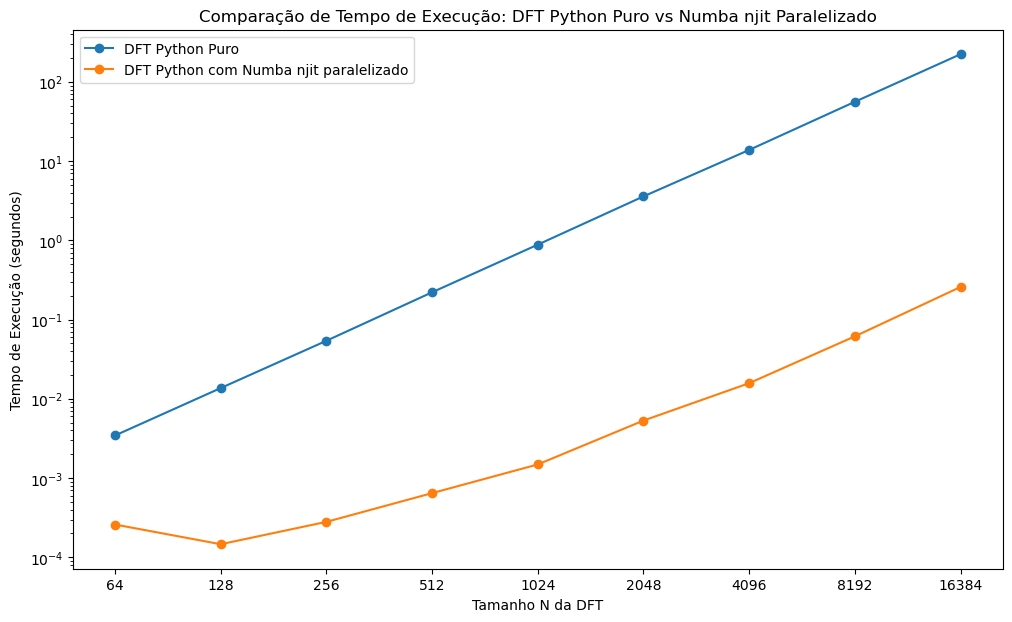

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func_Numba(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


dft_tamanhos= [64,128,256,512,1024,2048,4096,8192,16384]        
tempo_DFT= []
tempo_DFT_Numba= []

fs= 1000 # frequência de amostragem
f= 50 # frequência do sinal
A= 1 # amplitude do sinal
t= np.arange(-1,1,1/fs) # vetor tempo
x= A * np.sin(2 * np.pi * f * t) # sinal senoidal
x_noise= x + 0.5 * np.random.randn(len(t)) # sinal com ruído

print("Primeira Compilação com Numba (pode demorar um pouco)...")
DFT_func_Numba(x_noise, 100) # Compilação inicial com Numba
print("Compilação concluída. Iniciando os testes de tempo...")

for N in dft_tamanhos:
    print(f'Para N= {N}...')
    
    start_time= time.perf_counter()
    X_DFT= DFT_func(x_noise,N)
    end_time= time.perf_counter()
    time_spent= end_time - start_time
    tempo_DFT.append(time_spent)
    print(f'Tempo DFT com python puro: {time_spent} segundos')

    start_time_n= time.perf_counter()
    X_DFT= DFT_func_Numba(x_noise,N)
    end_time_n= time.perf_counter()
    time_spent_n= end_time_n - start_time_n
    tempo_DFT_Numba.append(time_spent_n)
    print(f'Tempo DFT tempo com python com njit paralelizado: {time_spent_n} segundos')

plt.figure(figsize=(12,7))
plt.plot(dft_tamanhos, tempo_DFT, marker='o', label='DFT Python Puro')
plt.plot(dft_tamanhos, tempo_DFT_Numba, marker='o', label='DFT Python com Numba njit paralelizado')
plt.yscale('log')
plt.xscale('log', base=2)
plt.xlabel('Tamanho N da DFT')
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Tempo de Execução: DFT Python Puro vs Numba njit Paralelizado')
plt.xticks (dft_tamanhos, labels=dft_tamanhos)
plt.legend()
plt.show()


    

A periodicidade da DFT, $X[k] = X[k+N]$, existe porque a base da transformada, os exponenciais complexos $W_N = e^{-j\frac{2\pi}{N}}$, são eles próprios periódicos. Vamos provar e visualizar isso.

A ideia é mostrar que os "vetores de base" (os exponenciais complexos) usados para calcular $X[k]$ são os mesmos usados para calcular $X[k+N]$.

O termo exponencial na DFT é $W_N^{kn} = e^{-j\frac{2\pi kn}{N}}$. Vamos ver o que acontece quando usamos $k' = k+N$:

$$
\begin{align*}
W_N^{(k+N)n} &= e^{-j\frac{2\pi(k+N)n}{N}} \\
             &= e^{-j\left(\frac{2\pi kn}{N} + \frac{2\pi Nn}{N}\right)} \\
             &= e^{-j\frac{2\pi kn}{N}} \cdot e^{-j2\pi n}
\end{align*}
$$

Pela Relação de Euler, sabemos que $e^{-j2\pi n} = \cos(2\pi n) - j\sin(2\pi n)$. Como $n$ é sempre um inteiro, $\cos(2\pi n) = 1$ e $\sin(2\pi n) = 0$. Portanto, $e^{-j2\pi n} = 1$.

Isso nos prova que:

$$
W_N^{(k+N)n} = W_N^{kn} \cdot 1 = W_N^{kn}
$$

Os termos exponenciais para o índice $k$ são idênticos aos termos para o índice $k+N$. Consequentemente, o somatório da DFT para $X[k]$ e $X[k+N]$ será o mesmo.

>>> Testando com uma chamada válida (k=3, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =10
Vamos provar que os termos para k=3 e (k + N)=13 são idênticos.
Verificação numérica: Os 10 termos são iguais? Sim.


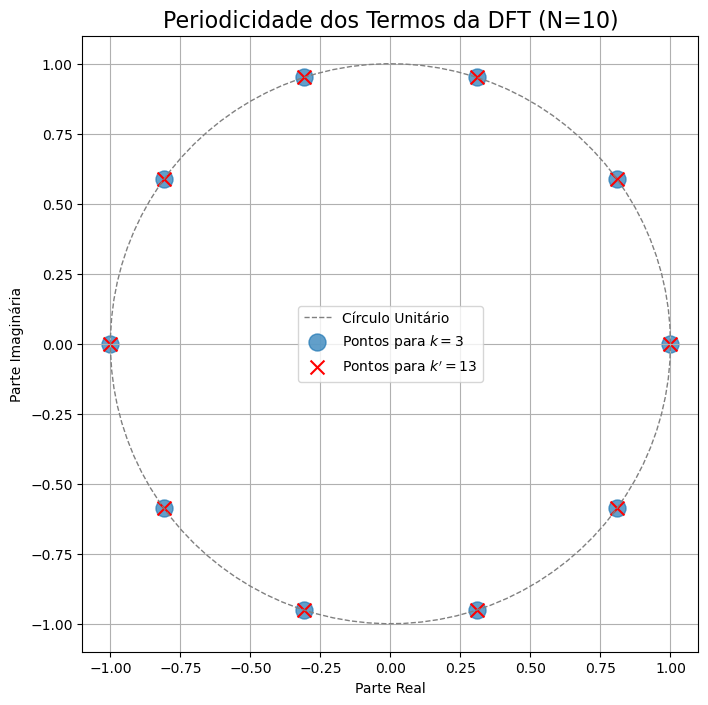

>>> Testando com uma chamada inválida (k=12, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =20
Vamos provar que os termos para k=12 e (k + N)=32 são idênticos.
Verificação numérica: Os 20 termos são iguais? Sim.


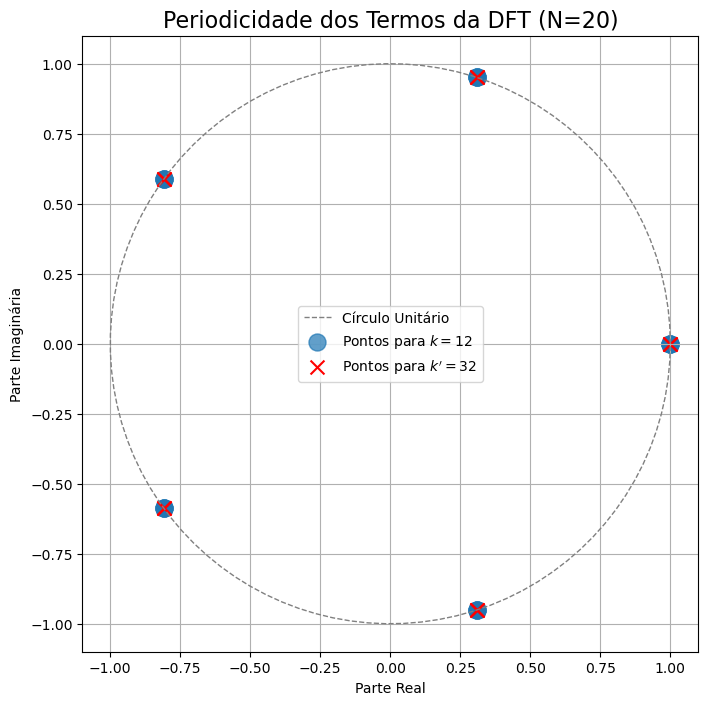

>>> Testando com uma chamada inválida no limite (k=10, N=10)...
Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N =10
ERRO: 'k_test' (10) deve ser menor que N (10).
A função será encerrada.


In [2]:
def DFT_periodic(N,k_test=2 ):
    print(f"Para Verificar a periodicidade da DFT, primeiro calculamos a DFT para N ={N}")

    if k_test >= N:
        print(f"ERRO: 'k_test' ({k_test}) deve ser menor que N ({N}).")
        print("A função será encerrada.")
        return # Encerra a função aqui.


    print(f"Vamos provar que os termos para k={k_test} e (k + N)={k_test+N} são idênticos.")
    n= np.arange(N)
    k= np.exp(-1j * 2 * np.pi * k_test * n / N)
    k_plus_N= np.exp(-1j * 2 * np.pi * (k_test + N) * n / N)

    print(f"Verificação numérica: Os {N} termos são iguais? {'Sim.' if np.allclose(k, k_plus_N) else 'Não.'}")

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'aspect': 'equal'})
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', linewidth=1, label='Círculo Unitário')
    ax.scatter(k.real, k.imag, marker='o', s=150, alpha=0.7, label=f'Pontos para $k={k_test}$')
    ax.scatter(k_plus_N.real, k_plus_N.imag, marker='x', s=100, color='red', label=f'Pontos para $k\'={k_test+N}$')
    ax.set_title(f'Periodicidade dos Termos da DFT (N={N})', fontsize=16)
    ax.set_xlabel('Parte Real')
    ax.set_ylabel('Parte Imaginária')
    ax.grid(True)
    ax.legend()
    plt.show()

print(">>> Testando com uma chamada válida (k=3, N=10)...")
DFT_periodic(N=10, k_test=3)


print(">>> Testando com uma chamada inválida (k=12, N=10)...")
DFT_periodic(N=20, k_test=12)


print(">>> Testando com uma chamada inválida no limite (k=10, N=10)...")
DFT_periodic(N=10, k_test=10)

# Propriedades de Simetria Conjugada da DFT

A **Transformada Discreta de Fourier (DFT)** é uma ferramenta fundamental na Análise de Sinais e Processamento Digital de Sinais (DSP).
Para um sinal discreto no tempo $x[n]$ de comprimento $N$, a DFT é definida por:

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, 2, \dots, N-1
$$

onde $X[k]$ são os coeficientes no **domínio da frequência**.

## Simetria Conjugada da DFT

Se a sequência $x[n]$ é **real**, os coeficientes da DFT satisfazem a importante propriedade de **simetria conjugada**:

$$
X^{*}[k] = X[N-k]
$$

Essa relação mostra que a DFT de sinais reais não é independente em todos os $N$ pontos de frequência:
os valores nos índices positivos e negativos (em sentido circular) estão relacionados pelo conjugado.

## Implicações da Simetria Conjugada

A partir da relação acima, seguem várias consequências para as partes real e imaginária, bem como para a magnitude e fase da DFT.

### 1. Parte Real – Simetria Par
Se
$$
X[k] = \operatorname{Re}\{X[k]\} + j\,\operatorname{Im}\{X[k]\},
$$
então
$$
\operatorname{Re}\{X[k]\} = \operatorname{Re}\{X[N-k]\}.
$$

Isso significa que a parte real da DFT é uma **sequência par** em torno de $N/2$.

### 2. Parte Imaginária – Simetria Ímpar
$$
\operatorname{Im}\{X[k]\} = -\operatorname{Im}\{X[N-k]\}.
$$

Portanto, a parte imaginária da DFT de um sinal real é **ímpar** em torno de $N/2$.

### 3. Magnitude – Simetria Par
$$
|X[k]| = |X[N-k]|.
$$

A magnitude do espectro apresenta **simetria par** em torno de $N/2$.

### 4. Fase – Simetria Ímpar
$$
\angle X[k] = -\angle X[N-k].
$$

A fase do espectro é uma **sequência ímpar** em torno de $N/2$.

## Coeficientes Reais Especiais

Existem dois coeficientes particularmente importantes:

- Para $k = 0$:
$$
X[0] = X[N-0] = X^{*}[0],
$$
logo $X[0]$ é **real** e representa a **componente DC** (nível médio do sinal).

- Se $N$ é par, para $k = N/2$:
$$
X\left[\frac{N}{2}\right] = X^{*}\left[\frac{N}{2}\right],
$$
ou seja, $X[N/2]$ também é **real** e representa a componente na frequência de **Nyquist**.

## Verificação Numérica com Python

Para validar essas propriedades, o programa em Python realiza os seguintes passos:

1. Gera uma sequência discreta real $x[n]$, por exemplo, uma soma de senos.
2. Calcula a DFT usando uma implementação direta.
3. Verifica numericamente as igualdades:
$$
X[k]^* \approx X[N-k],
$$
$$
\operatorname{Re}\{X[k]\} \approx \operatorname{Re}\{X[N-k]\},
$$
$$
\operatorname{Im}\{X[k]\} \approx -\operatorname{Im}\{X[N-k]\},
$$
$$
|X[k]| \approx |X[N-k]|
$$
4. Exibe gráficos mostrando a simetria de cada componente.

## Importância Prática

A simetria conjugada é extremamente útil no processamento digital de sinais:

- Permite otimizar algoritmos de FFT, reduzindo o número de cálculos para sinais reais.
- Facilita a interpretação espectral de sinais físicos (que são reais no tempo).
- Permite reconstruir o espectro completo a partir de apenas metade dos coeficientes.

Compreender e verificar numericamente essas propriedades é fundamental para a correta aplicação da DFT na análise de sinais reais.


Analisando: Sinal Real (deve obedecer simetria conjugada)
=== Verificação das Simetrias Conjugadas ===
k= 1: Re diff=+1.04e-15,  Im sum=-3.03e-15,  |X| diff=-2.56e-15,  fase sum=-3.79e+00
k= 2: Re diff=+6.78e-15,  Im sum=-5.21e-15,  |X| diff=-8.12e-15,  fase sum=-4.29e+00
k= 3: Re diff=-2.66e-15,  Im sum=+5.02e-15,  |X| diff=-2.66e-15,  fase sum=+1.77e-15
k= 4: Re diff=-4.38e-15,  Im sum=-2.20e-15,  |X| diff=-4.67e-15,  fase sum=-2.41e+00
k= 5: Re diff=+4.20e-15,  Im sum=-2.89e-15,  |X| diff=+2.89e-15,  fase sum=+2.89e-15
k= 6: Re diff=-8.10e-16,  Im sum=-3.37e-15,  |X| diff=-1.61e-15,  fase sum=-3.93e+00
k= 7: Re diff=-4.36e-15,  Im sum=+1.07e-15,  |X| diff=-4.05e-15,  fase sum=+1.19e+00
k= 8: Re diff=-3.94e-15,  Im sum=+1.78e-15,  |X| diff=-3.93e-15,  fase sum=-6.75e-01
k= 9: Re diff=-3.42e-15,  Im sum=-2.06e-15,  |X| diff=-1.36e-15,  fase sum=-2.36e+00
k=10: Re diff=-1.28e-15,  Im sum=-1.25e-15,  |X| diff=-1.07e-15,  fase sum=-2.87e+00
k=11: Re diff=-5.40e-15,  Im sum=-4.22e-16,  |

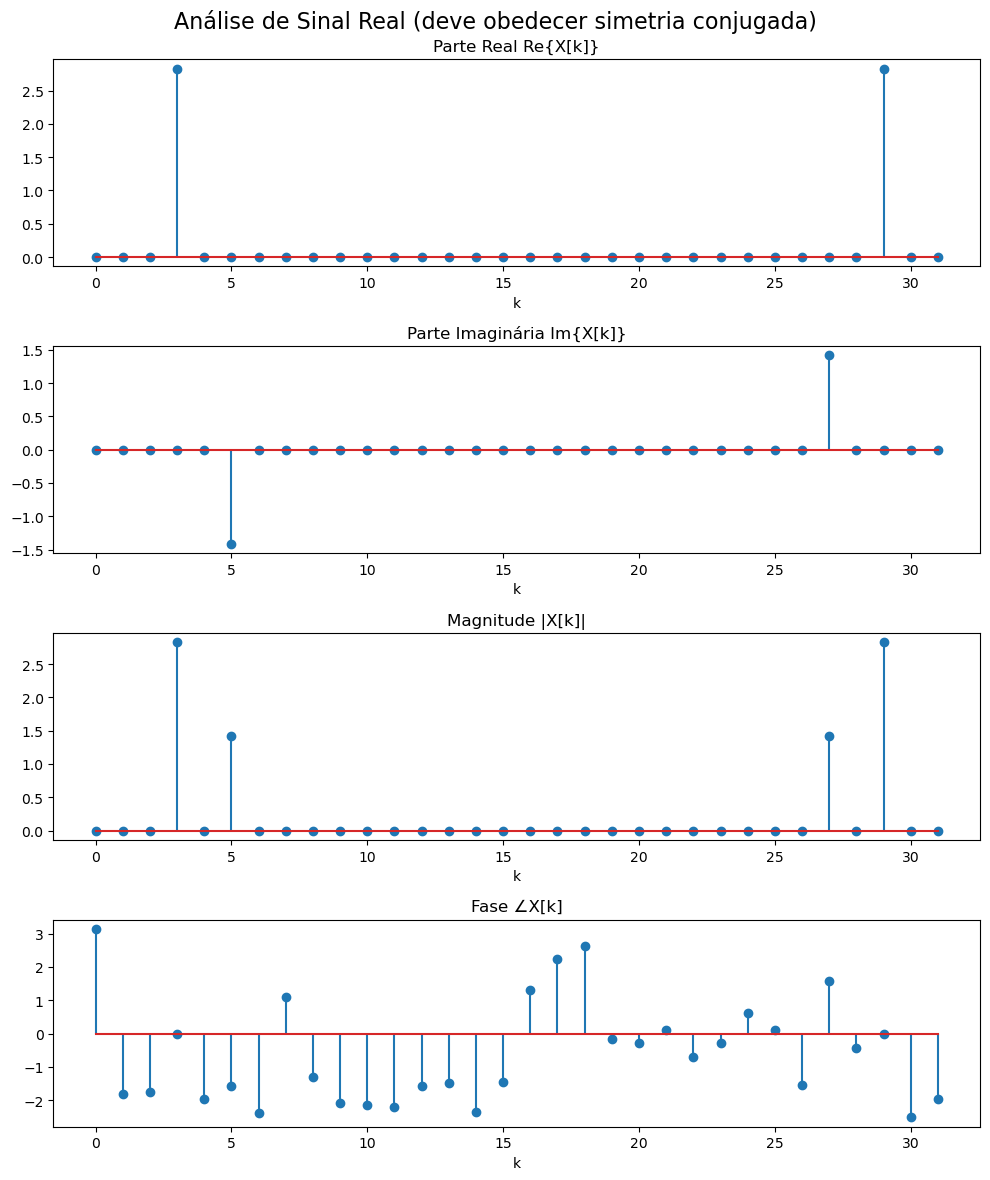


Analisando: Sinal Complexo (não obedece simetria conjugada)
=== Verificação das Simetrias Conjugadas ===
k= 1: Re diff=+9.62e-16,  Im sum=-2.41e-15,  |X| diff=-2.56e-15,  fase sum=+1.09e+00
k= 2: Re diff=+7.73e-15,  Im sum=-2.29e-15,  |X| diff=-8.03e-15,  fase sum=-2.89e-01
k= 3: Re diff=-2.66e-15,  Im sum=+8.00e-15,  |X| diff=-2.66e-15,  fase sum=+2.83e-15
k= 4: Re diff=-6.47e-15,  Im sum=+1.49e-15,  |X| diff=-6.45e-15,  fase sum=+1.48e+00
k= 5: Re diff=+2.83e+00,  Im sum=-1.40e-14,  |X| diff=+6.44e-15,  fase sum=-3.14e+00
k= 6: Re diff=+3.73e-16,  Im sum=-2.26e-15,  |X| diff=-6.99e-16,  fase sum=-4.66e+00
k= 7: Re diff=-4.05e-15,  Im sum=+2.87e-15,  |X| diff=-2.88e-15,  fase sum=+1.95e+00
k= 8: Re diff=-3.33e-15,  Im sum=+1.86e-15,  |X| diff=-2.83e-15,  fase sum=-1.22e+00
k= 9: Re diff=-2.15e-15,  Im sum=-3.14e-16,  |X| diff=+5.59e-16,  fase sum=-1.74e+00
k=10: Re diff=-1.23e-15,  Im sum=-2.08e-15,  |X| diff=-1.16e-15,  fase sum=-4.34e+00
k=11: Re diff=-5.59e-15,  Im sum=-4.71e-16, 

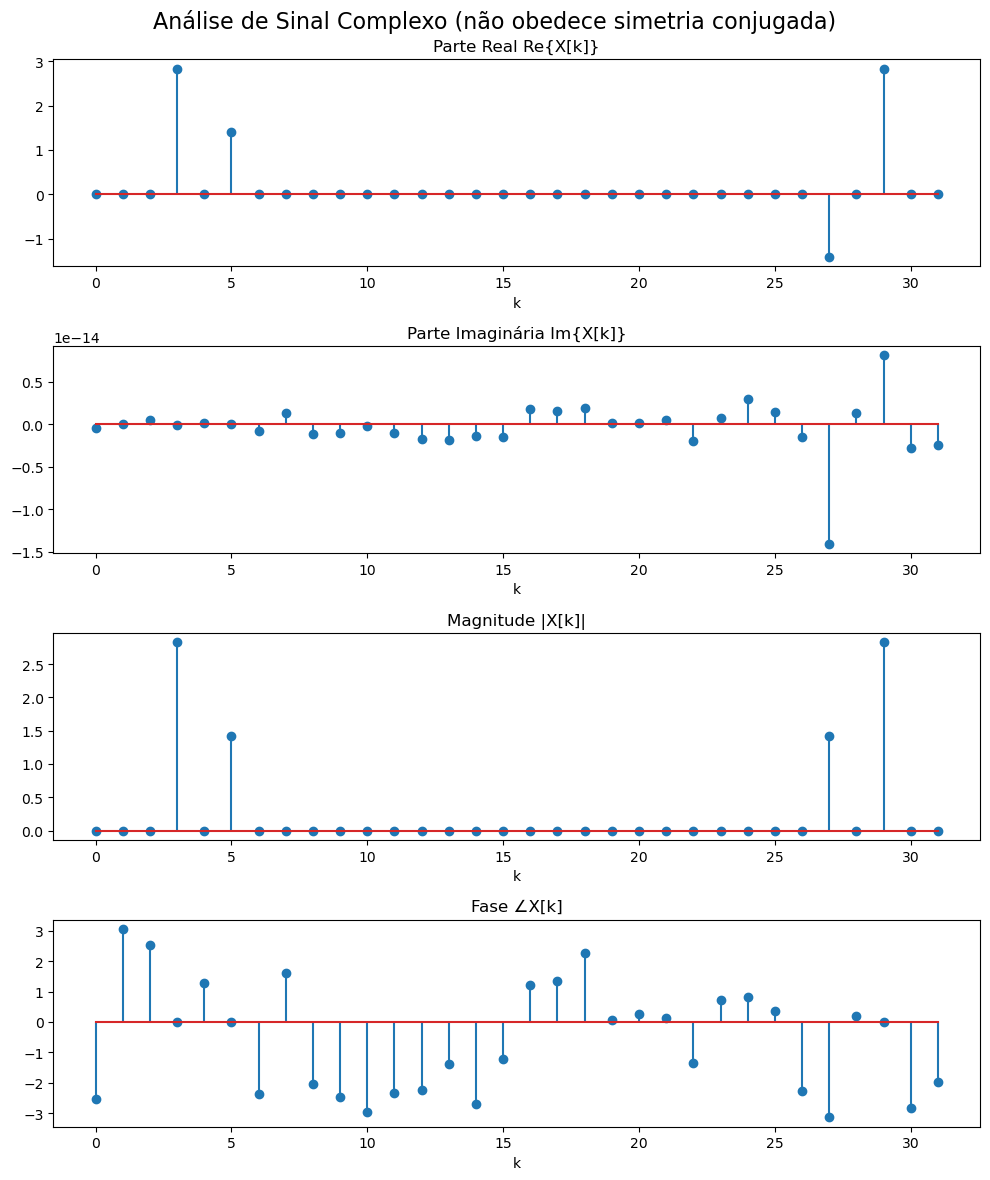

array([-6.28036983e-16-4.21962348e-16j, -5.88784672e-17+4.90653893e-18j,
       -6.67289295e-16+4.61214660e-16j,  2.82842712e+00-1.03037318e-16j,
        5.88784672e-17+1.96261557e-16j,  1.41421356e+00+5.88784672e-17j,
       -8.63550852e-16-8.24298541e-16j, -3.92523115e-17+1.39345706e-15j,
       -5.49532361e-16-1.09906472e-15j, -1.31004590e-15-1.05981241e-15j,
       -8.14485463e-16-1.37383090e-16j, -9.81307787e-16-1.04018625e-15j,
       -1.30513936e-15-1.66822324e-15j,  3.53270803e-16-1.78598017e-15j,
       -3.10093261e-15-1.41308321e-15j,  5.49532361e-16-1.51121399e-15j,
        6.67289295e-16+1.77616709e-15j,  3.53270803e-16+1.62406439e-15j,
       -1.60934477e-15+1.90373711e-15j,  2.00186788e-15+1.57009246e-16j,
        7.45793918e-16+1.86448479e-16j,  4.61214660e-15+5.69158516e-16j,
        4.12149270e-16-1.94298942e-15j,  8.43924697e-16+7.45793918e-16j,
        2.77710104e-15+2.96354952e-15j,  4.01354885e-15+1.47196168e-15j,
       -1.23644781e-15-1.43270937e-15j, -1.41421356

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange


# ------------------------------------------------------
# Função de demonstração das simetrias
# ------------------------------------------------------
def DFT_simetry(x, N, titulo=""):
    """
    Calcula a DFT de x[n] usando DFT_func,
    verifica as simetrias conjugadas e
    plota gráficos de Re, Im, |X| e fase.
    """
    print("\n======================================")
    print(f"Analisando: {titulo}")
    print("======================================")

    # 1. DFT
    X = DFT_func(x, N)

    # 2. Extrair componentes
    k = np.arange(N)
    Re_X = np.real(X)
    Im_X = np.imag(X)
    Mag_X = np.abs(X)
    Fase_X = np.angle(X)

    # 3. Verificação das simetrias
    print("=== Verificação das Simetrias Conjugadas ===")
    for k0 in range(1, N//2):    # exclui k=0 e N/2
        re_diff = Re_X[k0] - Re_X[N-k0]
        im_sum  = Im_X[k0] + Im_X[N-k0]
        mag_diff= Mag_X[k0] - Mag_X[N-k0]
        fase_sum= Fase_X[k0] + Fase_X[N-k0]
        print(f"k={k0:2d}: Re diff={re_diff:+.2e},  "
              f"Im sum={im_sum:+.2e},  "
              f"|X| diff={mag_diff:+.2e},  "
              f"fase sum={fase_sum:+.2e}")

    # Casos especiais
    print("\nCasos especiais:")
    print(f"X[0] = {X[0]}  (DC, deve ser real p/ sinal real)")
    if N % 2 == 0:
        print(f"X[N/2] = X[{N//2}] = {X[N//2]}  (frequência de Nyquist, deve ser real p/ sinal real)")

    # 4. Gráficos
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))
    fig.suptitle(f"Análise de {titulo}", fontsize=16)

    axs[0].stem(k, Re_X)
    axs[0].set_title("Parte Real Re{X[k]}")
    axs[0].set_xlabel("k")

    axs[1].stem(k, Im_X)
    axs[1].set_title("Parte Imaginária Im{X[k]}")
    axs[1].set_xlabel("k")

    axs[2].stem(k, Mag_X)
    axs[2].set_title("Magnitude |X[k]|")
    axs[2].set_xlabel("k")

    axs[3].stem(k, Fase_X)
    axs[3].set_title("Fase ∠X[k]")
    axs[3].set_xlabel("k")

    plt.tight_layout()
    plt.show()

    return X


N = 32
n = np.arange(N)

    # ---------- Sinal real ----------
x_real = np.cos(2*np.pi*3*n/N) + 0.5*np.sin(2*np.pi*5*n/N)

    # ---------- Sinal complexo ----------
x_complex = np.cos(2*np.pi*3*n/N) + 0.5j*np.sin(2*np.pi*5*n/N)

    # ---------- Análises ----------
DFT_simetry(x_real, N, "Sinal Real (deve obedecer simetria conjugada)")
DFT_simetry(x_complex, N, "Sinal Complexo (não obedece simetria conjugada)")
